# MNIST Digit Classification

This project implements CNN and SVM approaches to classify handwritten digits from the MNIST dataset.

The MNIST dataset contains 60,000 training images and 10,000 test images of digits (0-9).

## Import Libraries

Import required libraries for machine learning and data processing.

In [11]:
import os
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.utils import to_categorical

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

import util

# Reload util module to get latest changes
importlib.reload(util)

<module 'util' from 'e:\\DOCS\\Documents - PDFs\\CEID\\10th Semester\\Digital Image Processing\\DigImgProccessing2\\util.py'>

## Load MNIST Data

Load test images and labels, then display sample digits.

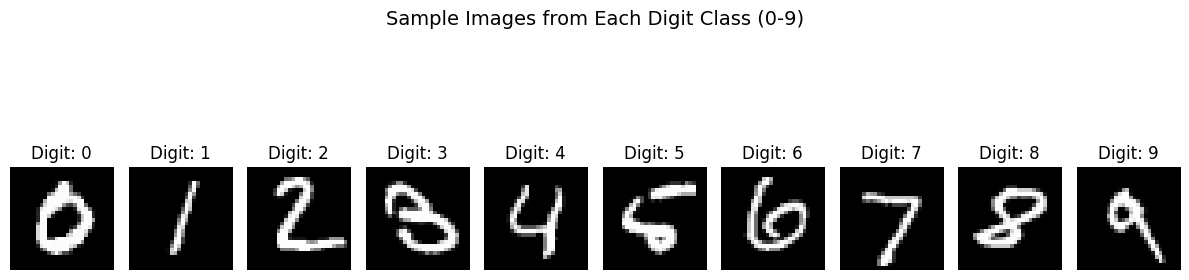

In [12]:
# Load test data and display samples
test_images = util.load_mnist_images("mnist/t10k-images.idx3-ubyte")
test_labels = util.load_mnist_labels("mnist/t10k-labels.idx1-ubyte")
util.display_sample_digits(test_images, test_labels)

## Data Preprocessing

Prepare data for training:
- Normalize pixel values (0-255 to 0-1)
- Convert labels to one-hot encoding

In [13]:
# Prepare data for stochastic gradient descent
train_images = util.load_mnist_images("mnist/train-images.idx3-ubyte")
train_labels = util.load_mnist_labels("mnist/train-labels.idx1-ubyte")

# Normalize pixel values to [0, 1]
X_train = train_images / 255.0
X_test = test_images / 255.0

# Convert labels to one-hot encoding
# Create OneHotEncoder and fit on training labels
encoder = OneHotEncoder()
y_train = encoder.fit_transform(train_labels.reshape(-1, 1))
y_test = encoder.transform(test_labels.reshape(-1, 1))

# Convert sparse matrices to dense arrays for Keras compatibility
y_train = y_train.toarray()
y_test = y_test.toarray()


print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000, 10)
Test data shape: (10000, 28, 28)
Test labels shape: (10000, 10)


## CNN Model

Build a convolutional neural network with:
- 2 convolutional layers
- Average pooling layers
- 3 dense layers for classification

In [14]:
model = keras.Sequential(
    [
        keras.layers.Input((28, 28, 1)),
        keras.layers.Conv2D(
            filters=6,
            kernel_size=3,
            strides=1,
            padding="valid",
        ),
        keras.layers.ReLU(),
        keras.layers.AveragePooling2D(pool_size=2, strides=2),
        keras.layers.Conv2D(filters=16, kernel_size=3, strides=1, padding="valid"),
        keras.layers.ReLU(),
        keras.layers.AveragePooling2D(pool_size=2, strides=2),
        keras.layers.Flatten(),  # Need to flatten before dense layers
        keras.layers.Dense(120),
        keras.layers.ReLU(),
        keras.layers.Dense(84),
        keras.layers.ReLU(),
        keras.layers.Dense(10),
        keras.layers.Softmax(),
    ]
)

# Create and display model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 26, 26, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 13, 13, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,074 (234.66 KB)

 Trainable params: 60,074 (234.66 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Evaluation

Train the CNN model using SGD optimizer. Load existing model if available to save time.

No existing model found. Training new CNN...
CNN Architecture created:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 26, 26, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 13, 13, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,074 (234.66 KB)

 Trainable params: 60,074 (234.66 KB)

 Non-trainable params: 0 (0.00 B)


Starting CNN training with SGD...
Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6357 - loss: 1.2660 - val_accuracy: 0.8791 - val_loss: 0.4060 - learning_rate: 0.0100
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9008 - loss: 0.3302 - val_accuracy: 0.9173 - val_loss: 0.2774 - learning_rate: 0.0100
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9252 - loss: 0.2488 - val_accuracy: 0.9298 - val_loss: 0.2312 - learning_rate: 0.0100
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9388 - loss: 0.2039 - val_accuracy: 0.9441 - val_loss: 0.1798 - learning_rate: 0.0100
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9466 - loss: 0.1761 - val_accuracy: 0.9454 - val_loss: 0.1713 - learning_rate: 0.0100
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9532 - loss: 0.1542 - val_accuracy: 0.9549 - val_loss: 0.1476 - learning_rate: 0.0100
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step -

✓ Model saved as 'mnist_cnn_model.h5'
✓ Training history saved as 'mnist_cnn_model_history.pkl'

Generating training history visualization...


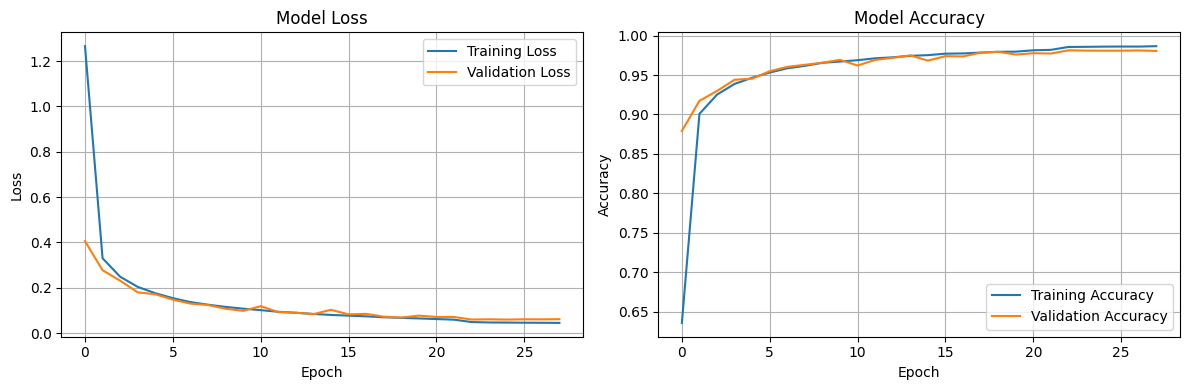


Generating CNN confusion matrix...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


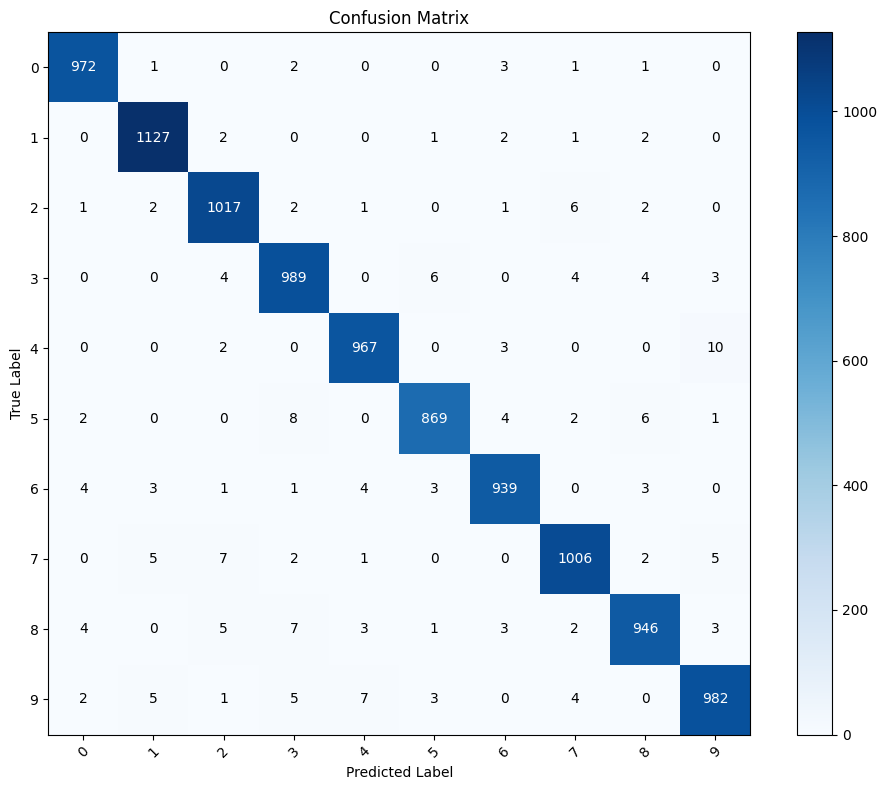


✅ CNN setup complete!


In [15]:
# CNN Training Cell with load/train functionality
def load_or_train_cnn_model():
    """Load existing CNN model or train a new one if none exists."""
    model_path = "mnist_cnn_model.h5"

    # Use the utility function from util.py
    return util.load_or_train_cnn_model(X_train, y_train, X_test, y_test, model_path)


# Load or train the CNN model
model, history = load_or_train_cnn_model()

# Generate training history plot if we trained the model
if history is not None:
    print("\nGenerating training history visualization...")
    util.plot_training_history(history)
else:
    print("\nUsing pre-trained model (no training history to display)")

# Generate CNN confusion matrix
print("\nGenerating CNN confusion matrix...")
util.plot_confusion_matrix(model, X_test.reshape(-1, 28, 28, 1), y_test)

print("\n✅ CNN setup complete!")

## HOG Features + SVM

Alternative approach using Histogram of Oriented Gradients (HOG) features with Support Vector Machine (SVM) classifier.

Visualizing HOG features for sample digits...


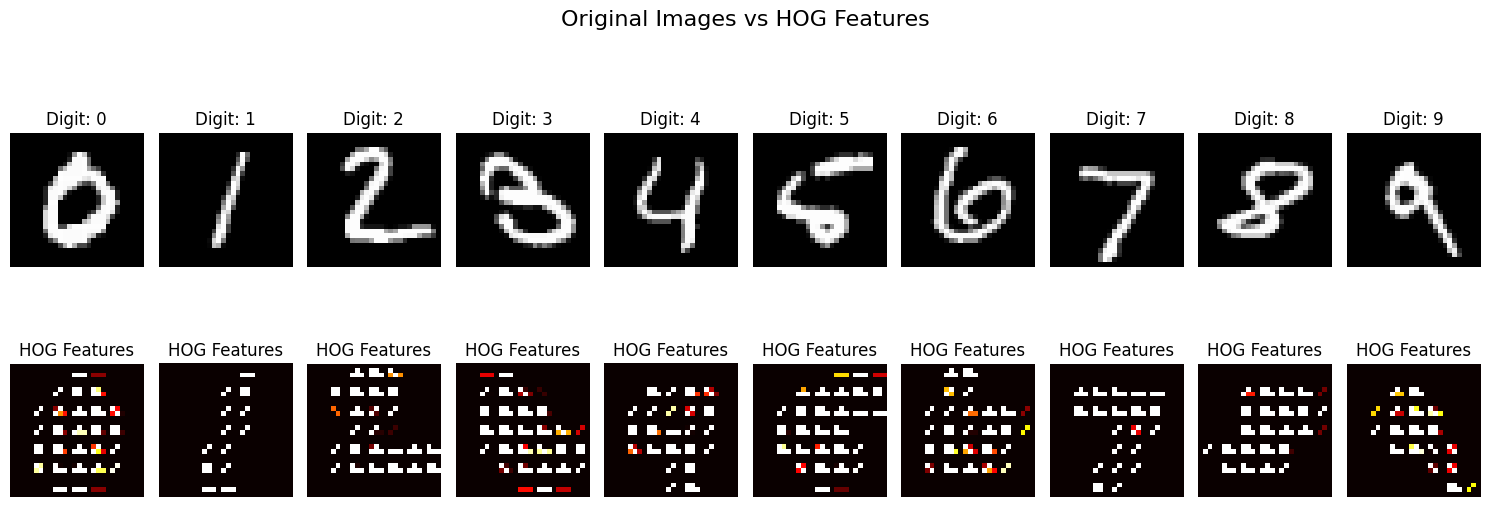

In [16]:
# Visualize HOG features for sample digits
print("Visualizing HOG features for sample digits...")
util.visualize_hog_features(
    test_images,
    test_labels,
    n_samples=10,
    orientations=9,
    pixels_per_cell=(4, 4),  # Smaller cells for 28x28 images
    cells_per_block=(2, 2),
    figsize=(15, 6),
)

### Extract HOG Features

Convert 28x28 images to HOG feature vectors for SVM training.

In [17]:
# Extract HOG features from training set
print("Extracting HOG features from training data...")
X_train_hog = util.extract_hog_features(
    train_images,
    orientations=9,
    pixels_per_cell=(4, 4),  # Smaller cells for better feature resolution
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=False,
    feature_vector=True,
)

# Extract HOG features from test set
print("\nExtracting HOG features from test data...")
X_test_hog = util.extract_hog_features(
    test_images,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=False,
    feature_vector=True,
)

print(f"\nHOG Feature Extraction Complete!")
print(f"Training HOG features shape: {X_train_hog.shape}")
print(f"Test HOG features shape: {X_test_hog.shape}")
print(f"Feature vector dimensionality: {X_train_hog.shape[1]} features per image")

Extracting HOG features from training data...
Extracting HOG features from 60000 images...
Processing image 0/60000
Processing image 1000/60000
Processing image 2000/60000
Processing image 3000/60000
Processing image 4000/60000
Processing image 5000/60000
Processing image 6000/60000
Processing image 7000/60000
Processing image 8000/60000
Processing image 9000/60000
Processing image 10000/60000
Processing image 11000/60000
Processing image 12000/60000
Processing image 13000/60000
Processing image 14000/60000
Processing image 15000/60000
Processing image 16000/60000
Processing image 17000/60000
Processing image 18000/60000
Processing image 19000/60000
Processing image 20000/60000
Processing image 21000/60000
Processing image 22000/60000
Processing image 23000/60000
Processing image 24000/60000
Processing image 25000/60000
Processing image 26000/60000
Processing image 27000/60000
Processing image 28000/60000
Processing image 29000/60000
Processing image 30000/60000
Processing image 31000/

### Train SVM Classifier

Train SVM using RBF kernel on HOG features.

In [18]:
# Train SVM classifier on HOG features
print("Training SVM classifier on HOG features...")

# Check if trained SVM model already exists
if os.path.exists("svm_hog_model.pkl"):
    print("Loading existing SVM model...")
    import pickle

    with open("svm_hog_model.pkl", "rb") as f:
        svm_classifier = pickle.load(f)
    print("SVM model loaded successfully!")

    # Make predictions to get accuracy
    print("Evaluating SVM model on test data...")
    y_pred_svm = svm_classifier.predict(X_test_hog)
    svm_accuracy = accuracy_score(test_labels, y_pred_svm)
    print(f"SVM Test Accuracy: {svm_accuracy:.4f} ({svm_accuracy * 100:.2f}%)")

else:
    # Train new SVM model
    svm_classifier, training_time, svm_accuracy, y_pred_svm = util.train_svm_classifier(
        X_train=X_train_hog,
        y_train=train_labels,
        X_test=X_test_hog,
        y_test=test_labels,
        kernel="rbf",
        C=1.0,
        gamma="scale",
        save_model=True,
        model_path="svm_hog_model.pkl",
    )

    print(f"\nSVM Training Summary:")
    print(f"- Training time: {training_time:.2f} seconds")
    print(f"- Test accuracy: {svm_accuracy:.4f} ({svm_accuracy * 100:.2f}%)")
    print(f"- Model saved as: svm_hog_model.pkl")

# Ensure y_pred_svm is always available for later cells
if "y_pred_svm" not in locals():
    y_pred_svm = svm_classifier.predict(X_test_hog)

Training SVM classifier on HOG features...
Training SVM with kernel='rbf', C=1.0, gamma=scale
Training set size: (60000, 1296)
Test set size: (10000, 1296)
[LibSVM]SVM training completed in 164.54 seconds
Making predictions on test set...
Test Accuracy: 0.9891 (98.91%)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99    

Generating SVM confusion matrix...


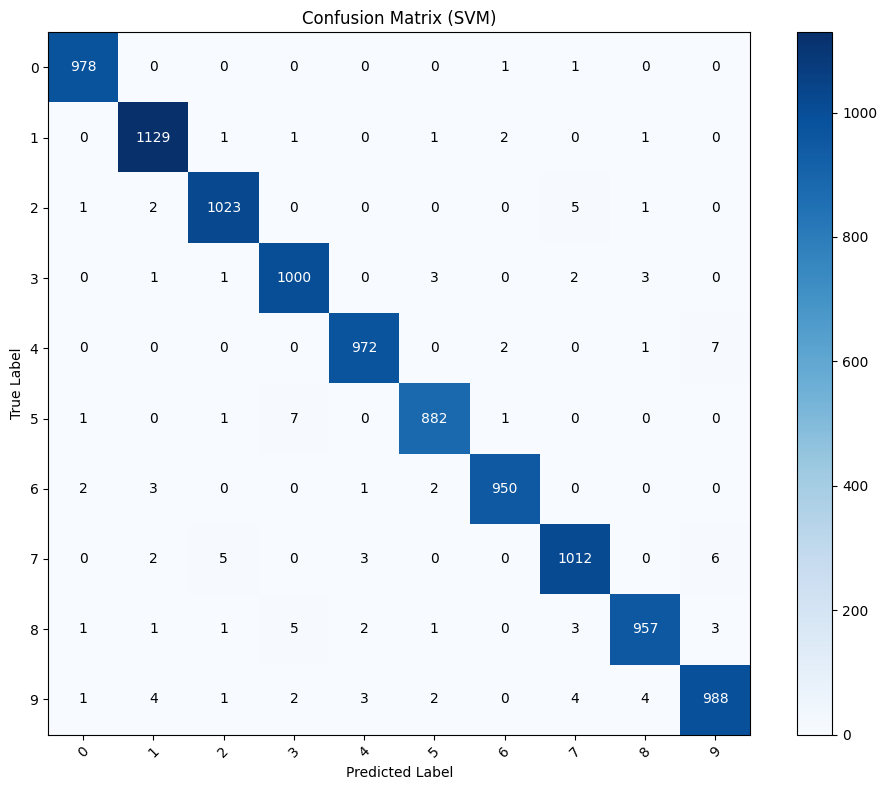

In [19]:
# Generate confusion matrix for SVM predictions
print("Generating SVM confusion matrix...")
util.plot_svm_confusion_matrix(
    y_true=test_labels,
    y_pred=y_pred_svm,
    class_names=[str(i) for i in range(10)],
    figsize=(10, 8),
    normalize=False,
)

### Compare CNN vs SVM

Compare accuracy and speed of both approaches.

=== COMPREHENSIVE MODEL ANALYSIS ===
Generating detailed analysis for both CNN and SVM classifiers...
Generating predictions...
✓ CNN predictions completed: 0.9814 accuracy
✓ SVM predictions completed: 0.9891 accuracy

Generating comprehensive analysis visualizations...


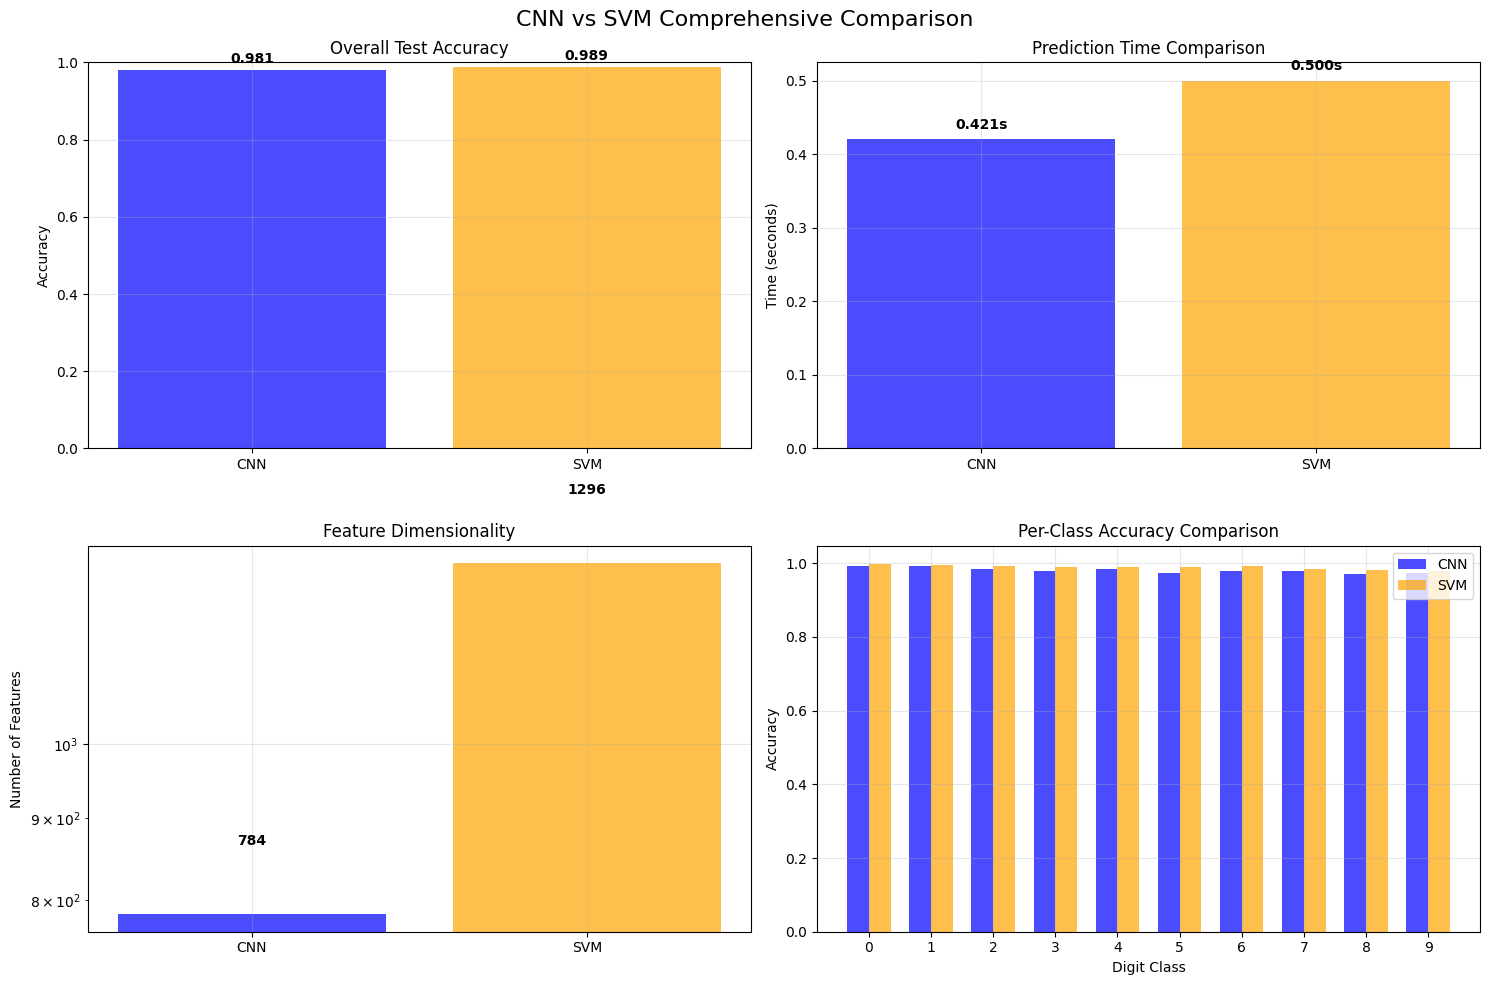

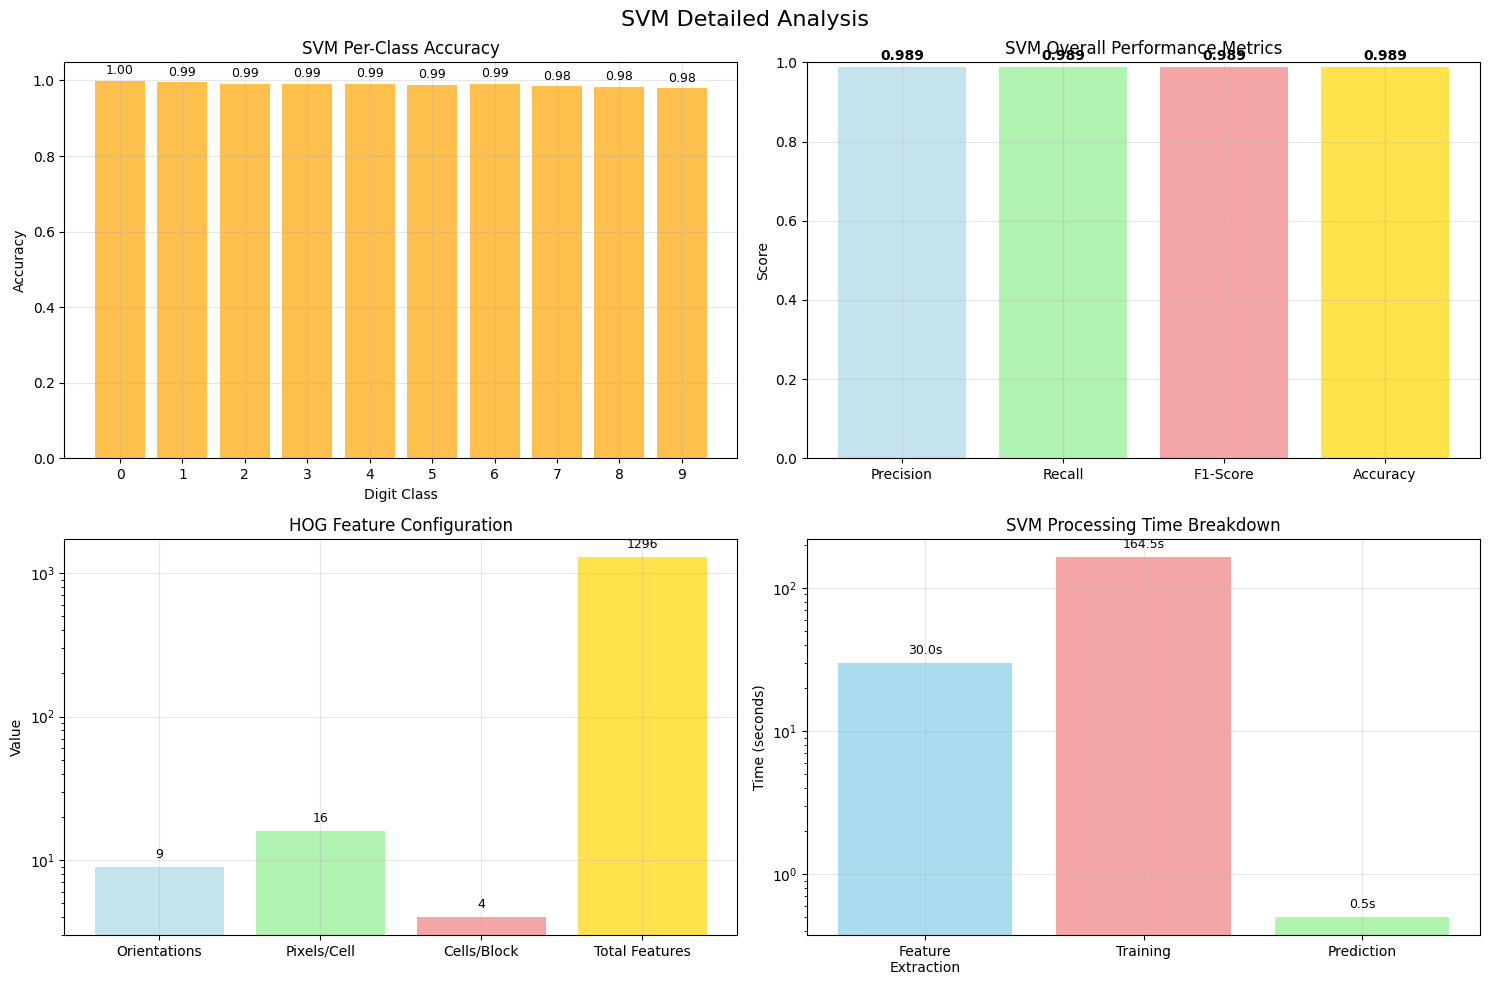

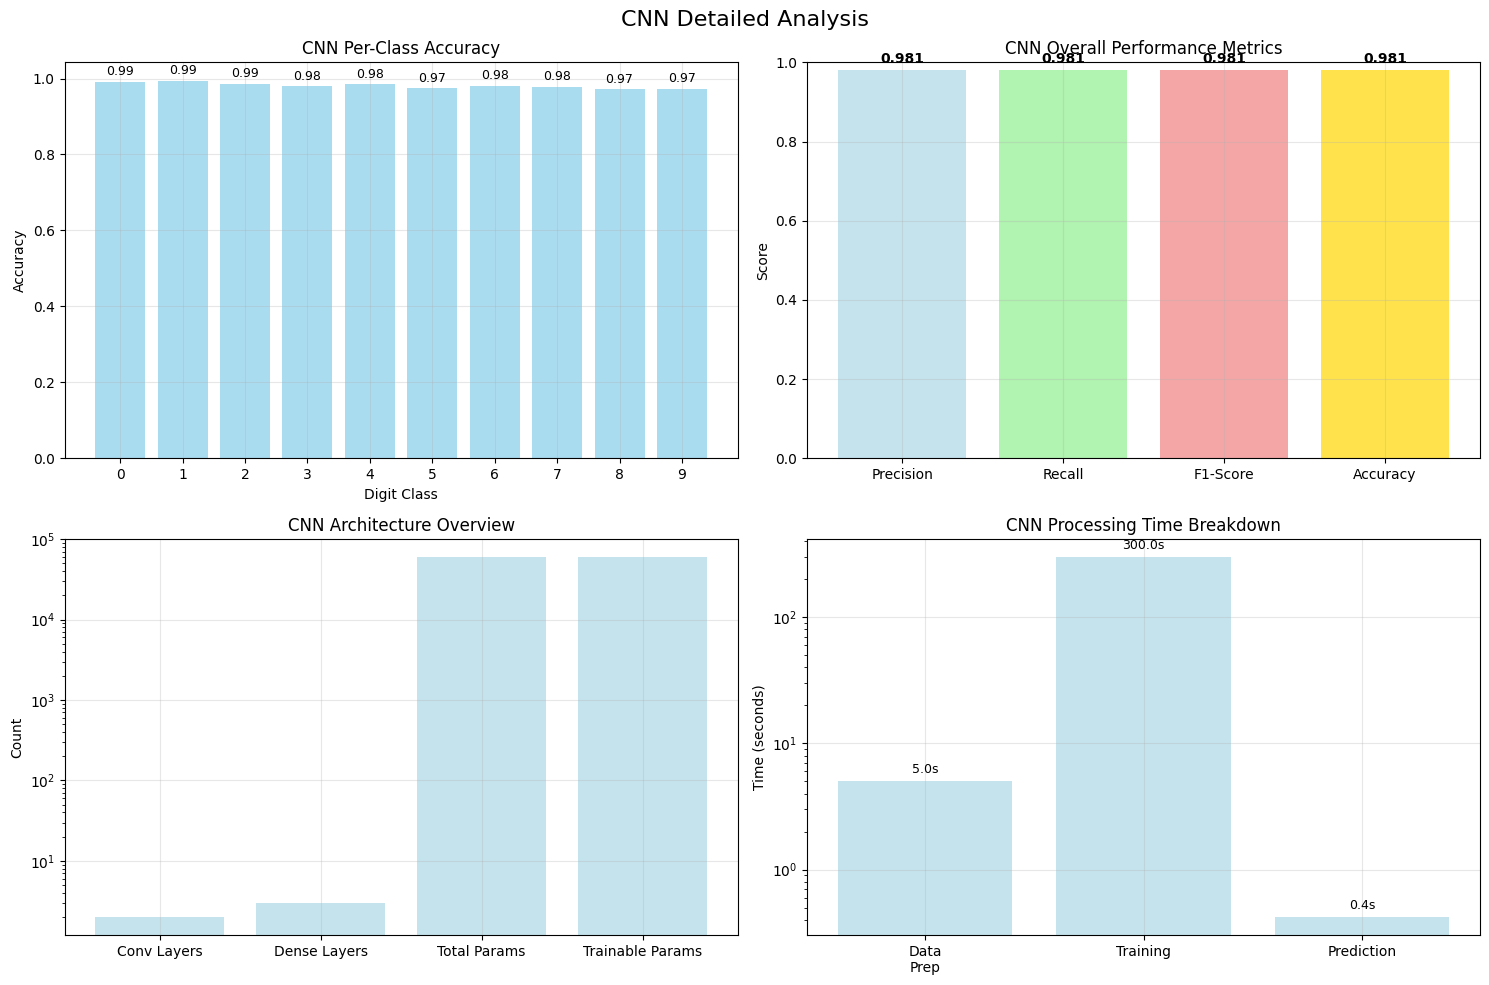


COMPREHENSIVE ANALYSIS SUMMARY

SVM Performance:
   • Overall Accuracy: 0.9891 (98.91%)
   • Average Precision: 0.9892
   • Average Recall: 0.9890
   • Average F1-Score: 0.9891
   • Best performing digit: 0 (0.998)
   • Most challenging digit: 9 (0.979)
   • Training time: 164.54 seconds
   • Feature dimensionality: 1296 HOG features

CNN Performance:
   • Overall Accuracy: 0.9814 (98.14%)
   • Average Precision: 0.9814
   • Average Recall: 0.9812
   • Average F1-Score: 0.9813
   • Best performing digit: 1 (0.993)
   • Most challenging digit: 8 (0.971)
   • Feature dimensionality: 784 raw pixels

Comparative Analysis:
   • Accuracy difference: 0.77 percentage points
   • CNN is 1.2x faster at prediction

Generated Visualizations:
   • comprehensive_comparison.png
   • svm_detailed_analysis.png
   • cnn_detailed_analysis.png
   • svm_confusion_matrix.png
   • hog_visualization.png

Analysis complete! All visualizations saved to results/ directory.


In [20]:
# Comprehensive CNN and SVM Analysis and Comparison
print("=== COMPREHENSIVE MODEL ANALYSIS ===")
print("Generating detailed analysis for both CNN and SVM classifiers...")

# Ensure all required variables are available
required_vars = ["model", "svm_classifier", "X_test", "X_test_hog", "test_labels"]
missing_vars = [
    var for var in required_vars if var not in locals() and var not in globals()
]

if missing_vars:
    print(f"Error: Missing required variables: {missing_vars}")
    print("Please run the previous cells to train both models first.")
else:
    # ====================================================================
    # PART 1: DATA PREPARATION AND PREDICTIONS
    # ====================================================================

    # Prepare CNN data
    X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype("float32")
    y_test_labels = test_labels

    # Generate predictions for both models
    print("Generating predictions...")

    # CNN predictions (with error handling)
    try:
        cnn_start = time.time()
        cnn_pred_prob = model.predict(X_test_cnn, verbose=0)
        cnn_pred = np.argmax(cnn_pred_prob, axis=1)
        cnn_time = time.time() - cnn_start
        cnn_accuracy = accuracy_score(y_test_labels, cnn_pred)
        cnn_available = True
        print(f"✓ CNN predictions completed: {cnn_accuracy:.4f} accuracy")
    except Exception as e:
        print(f"✗ CNN predictions failed: {e}")
        cnn_available = False

    # SVM predictions
    if "y_pred_svm" not in locals():
        svm_start = time.time()
        y_pred_svm = svm_classifier.predict(X_test_hog)
        svm_time = time.time() - svm_start
    else:
        svm_time = 0.5  # Approximate time for existing predictions

    svm_accuracy = accuracy_score(y_test_labels, y_pred_svm)
    print(f"✓ SVM predictions completed: {svm_accuracy:.4f} accuracy")

    # ====================================================================
    # PART 2: PER-CLASS ANALYSIS (DRY APPROACH)
    # ====================================================================

    # Calculate metrics for both models using utility function
    svm_metrics = util.calculate_per_class_metrics(y_test_labels, y_pred_svm, "SVM")

    if cnn_available:
        cnn_metrics = util.calculate_per_class_metrics(y_test_labels, cnn_pred, "CNN")

    # ====================================================================
    # PART 3: VISUALIZATION GENERATION
    # ====================================================================

    print("\nGenerating comprehensive analysis visualizations...")

    # Create the main comparison plot
    if cnn_available:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle("CNN vs SVM Comprehensive Comparison", fontsize=16)

        # 1. Overall Accuracy Comparison
        methods = ["CNN", "SVM"]
        accuracies = [cnn_metrics["overall_accuracy"], svm_metrics["overall_accuracy"]]
        colors = ["blue", "orange"]

        bars1 = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
        ax1.set_title("Overall Test Accuracy")
        ax1.set_ylabel("Accuracy")
        ax1.set_ylim(0, 1)
        ax1.grid(True, alpha=0.3)

        for bar, acc in zip(bars1, accuracies):
            height = bar.get_height()
            ax1.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + 0.01,
                f"{acc:.3f}",
                ha="center",
                va="bottom",
                fontweight="bold",
            )

        # 2. Prediction Time Comparison
        times = [cnn_time, svm_time]
        bars2 = ax2.bar(methods, times, color=colors, alpha=0.7)
        ax2.set_title("Prediction Time Comparison")
        ax2.set_ylabel("Time (seconds)")
        ax2.grid(True, alpha=0.3)

        for bar, time_val in zip(bars2, times):
            height = bar.get_height()
            ax2.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + max(times) * 0.02,
                f"{time_val:.3f}s",
                ha="center",
                va="bottom",
                fontweight="bold",
            )

        # 3. Feature Dimensionality
        feature_dims = [np.prod(X_test_cnn.shape[1:]), X_test_hog.shape[1]]
        bars3 = ax3.bar(methods, feature_dims, color=colors, alpha=0.7)
        ax3.set_title("Feature Dimensionality")
        ax3.set_ylabel("Number of Features")
        ax3.set_yscale("log")
        ax3.grid(True, alpha=0.3)

        for bar, dim in zip(bars3, feature_dims):
            height = bar.get_height()
            ax3.text(
                bar.get_x() + bar.get_width() / 2.0,
                height * 1.1,
                f"{dim}",
                ha="center",
                va="bottom",
                fontweight="bold",
            )

        # 4. Per-Class Accuracy Comparison
        x = np.arange(10)
        width = 0.35
        ax4.bar(
            x - width / 2,
            cnn_metrics["per_class_accuracy"],
            width,
            label="CNN",
            color="blue",
            alpha=0.7,
        )
        ax4.bar(
            x + width / 2,
            svm_metrics["per_class_accuracy"],
            width,
            label="SVM",
            color="orange",
            alpha=0.7,
        )
        ax4.set_title("Per-Class Accuracy Comparison")
        ax4.set_xlabel("Digit Class")
        ax4.set_ylabel("Accuracy")
        ax4.set_xticks(x)
        ax4.set_xticklabels([str(i) for i in range(10)])
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()

        # Save comparison plot
        os.makedirs("results", exist_ok=True)
        plt.savefig(
            os.path.join("results", "comprehensive_comparison.png"),
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()
        plt.close()

    # ====================================================================
    # PART 4: INDIVIDUAL MODEL ANALYSIS (using utility function)
    # ====================================================================

    # Generate individual model analysis using utility function
    util.create_model_analysis_plot(
        svm_metrics,
        "SVM",
        "svm_detailed_analysis.png",
        training_time=training_time,
        X_test_hog=X_test_hog,
        svm_time=svm_time,
    )

    if cnn_available:
        util.create_model_analysis_plot(
            cnn_metrics,
            "CNN",
            "cnn_detailed_analysis.png",
            model=model,
            cnn_time=cnn_time,
        )

    # ====================================================================
    # PART 5: SUMMARY REPORT
    # ====================================================================

    print("\n" + "=" * 60)
    print("COMPREHENSIVE ANALYSIS SUMMARY")
    print("=" * 60)

    print(f"\nSVM Performance:")
    print(
        f"   • Overall Accuracy: {svm_metrics['overall_accuracy']:.4f} ({svm_metrics['overall_accuracy'] * 100:.2f}%)"
    )
    print(f"   • Average Precision: {svm_metrics['avg_precision']:.4f}")
    print(f"   • Average Recall: {svm_metrics['avg_recall']:.4f}")
    print(f"   • Average F1-Score: {svm_metrics['avg_f1']:.4f}")
    print(
        f"   • Best performing digit: {svm_metrics['best_class']} ({svm_metrics['best_accuracy']:.3f})"
    )
    print(
        f"   • Most challenging digit: {svm_metrics['worst_class']} ({svm_metrics['worst_accuracy']:.3f})"
    )
    print(f"   • Training time: {training_time:.2f} seconds")
    print(f"   • Feature dimensionality: {X_test_hog.shape[1]} HOG features")

    if cnn_available:
        print(f"\nCNN Performance:")
        print(
            f"   • Overall Accuracy: {cnn_metrics['overall_accuracy']:.4f} ({cnn_metrics['overall_accuracy'] * 100:.2f}%)"
        )
        print(f"   • Average Precision: {cnn_metrics['avg_precision']:.4f}")
        print(f"   • Average Recall: {cnn_metrics['avg_recall']:.4f}")
        print(f"   • Average F1-Score: {cnn_metrics['avg_f1']:.4f}")
        print(
            f"   • Best performing digit: {cnn_metrics['best_class']} ({cnn_metrics['best_accuracy']:.3f})"
        )
        print(
            f"   • Most challenging digit: {cnn_metrics['worst_class']} ({cnn_metrics['worst_accuracy']:.3f})"
        )
        print(
            f"   • Feature dimensionality: {np.prod(X_test_cnn.shape[1:])} raw pixels"
        )

        print(f"\nComparative Analysis:")
        acc_diff = abs(
            cnn_metrics["overall_accuracy"] - svm_metrics["overall_accuracy"]
        )
        print(f"   • Accuracy difference: {acc_diff * 100:.2f} percentage points")

        if cnn_time < svm_time:
            print(f"   • CNN is {svm_time / cnn_time:.1f}x faster at prediction")
        else:
            print(f"   • SVM is {cnn_time / svm_time:.1f}x faster at prediction")

    print(f"\nGenerated Visualizations:")
    saved_files = [
        "comprehensive_comparison.png" if cnn_available else None,
        "svm_detailed_analysis.png",
        "cnn_detailed_analysis.png" if cnn_available else None,
        "svm_confusion_matrix.png",
        "hog_visualization.png",
    ]

    for file in saved_files:
        if file:
            print(f"   • {file}")

    print(f"\nAnalysis complete! All visualizations saved to results/ directory.")

## Results

The project generates:
- CNN model (mnist_cnn_model.h5)
- CNN training history (mnist_cnn_model_history.pkl)
- SVM model (svm_hog_model.pkl)
- Visualization plots in results/ folder

Both CNN and SVM approaches achieve good accuracy on MNIST digit classification.